<a href="https://colab.research.google.com/github/Optimized-Brain/Quantum-Percolation/blob/main/PercolationTheory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pylab import *
from scipy.ndimage import measurements
from scipy.ndimage import label
from skimage import measure, morphology
from PIL import Image
from matplotlib import pyplot as plt

# Defining Nearest Neighbour Clusters for 2D Percolating Model

In [ ]:
def get_neighbourhood_and_pc(str):
    #'NN' = nearest neighbours
    # 0 1 0
    # 1 X 1 (X is the reference, 1s are neighbours and 0s are not)
    # 0 1 0
    #'NNN' = next-nearest neighbours
    # 1 1 1
    # 1 X 1
    # 1 1 1
    #'tri' = triangular
    # 1 1 0
    # 1 X 1
    # 0 1 1

    # pc = the associated critical density
    if str == 'NN':
        pc = 0.592
        neighbourKernal = array([[0, 1, 0],[1, 1, 1], [0, 1, 0]])
    elif str == 'NNN':
        pc = 0.407
        neighbourKernal = array([[1, 1, 1],[1, 1, 1], [1, 1, 1]])
    elif str == 'tri':
        pc = 0.5
        neighbourKernal = array([[1, 1, 0],[1, 1, 1], [0, 1, 1]])

    return neighbourKernal, pc

In [ ]:
#Choose the neighbourhood type
neigh = 'tri'
neighbourKernal, pc = get_neighbourhood_and_pc(neigh)


# Determining the Percolating Cluster based on Grind Density



In [ ]:
density_list = [0, 0.1, 0.2, 0.8, 0.9, 1]
#most of the samples will be between 0.4 and 0.6
num_densities = 20
density_list = append(density_list, linspace(0.3,0.7,num_densities))
density_list.sort()

# set the grid size along one dimension
# total grid will be size grid_size*grid_size
grid_size = 200

# set number of random trials
nsamp = 500


Pi = np.zeros((len(density_list), 1)) #probabilities will go here
for dd in range(len(density_list)):
    density = density_list[dd]

    for trial in range(nsamp):

        #make a random grid
        z = rand(grid_size,grid_size)
        #values less than the density are set to 0, otherwise 1
        m = z<density

        #test to see if there is a percolating cluster
        lw, num = measurements.label(m, neighbourKernal)
        perc_x = intersect1d(lw[0,:],lw[-1,:])
        perc = perc_x[where(perc_x>0)]
        if len(perc) > 0:
            #if there is a percolating cluster update the probability
            Pi[dd] += 1


percProb = Pi/nsamp

<ipython-input-4-7e74d09ab7f0>:27: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  lw, num = measurements.label(m, neighbourKernal)


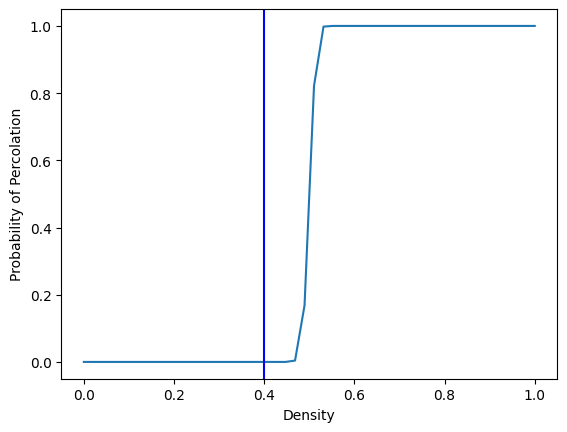

In [ ]:
#If neigh ='tri' you should see a sharp increase around 0.6
#this means 0.6 is roughly the critical density
plot(density_list, percProb[:])
plt.axvline(x = 0.4, color = 'b', label = 'axvline - full height')
ylabel('Probability of Percolation')
xlabel('Density');

# Performing Cluster Analysis for Different Densities

<ipython-input-5-2d80f1882d34>:16: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  lw = measurements.label(m, neighbourKernal)
<ipython-input-5-2d80f1882d34>:22: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  area = measurements.sum(m, lw, index=arange(lw.max() + 1))


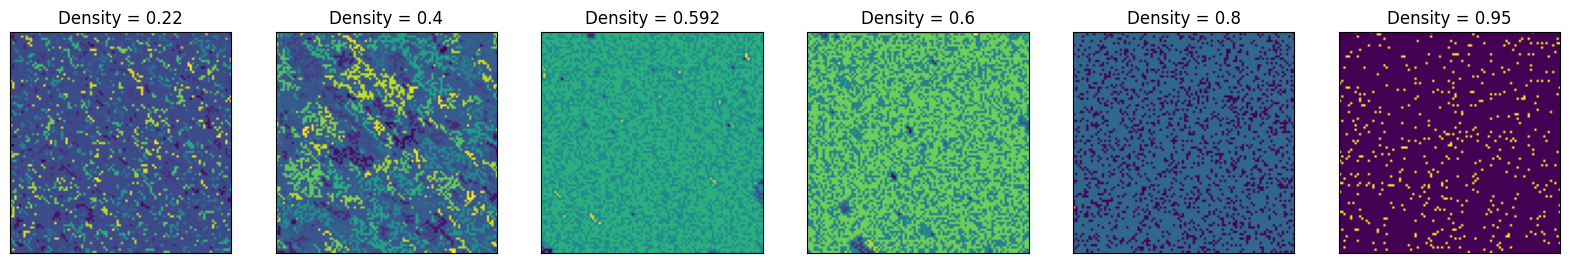

In [ ]:

#lets look at how the grid looks like below, at, and above the critical density
grid_size = 100
#0.592 is the true critical point for NN and 0.6 is the estimate from the previous graph
density_list = [0.22,0.4, 0.592,0.6, 0.8,0.95]

count = 0
fig, axs = plt.subplots(1,6)

default_coloring = False

for density in density_list:
    #make a random grid of 0s and 1s
    z = rand(grid_size,grid_size)
    m = z<density

    lw = measurements.label(m, neighbourKernal)
    lw = lw[0]

    if default_coloring:
        axs[count].imshow(lw)
    else:
        area = measurements.sum(m, lw, index=arange(lw.max() + 1))
        colors = np.random.permutation(len(area)) #randomize the colors for better visibility
        areaImg = colors[lw]
        axs[count].imshow(areaImg)


    axs[count].set_title('Density = ' + str(density))
    axs[count].set_xticks([])
    axs[count].set_yticks([])

    count += 1

    fig.set_size_inches(20, 20)
    #fig.savefig('test2png.png', dpi=100)

# Isolating Largest Cluster

<ipython-input-6-7aa0438c9fe0>:19: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  lw = measurements.label(m, neighbourKernal)


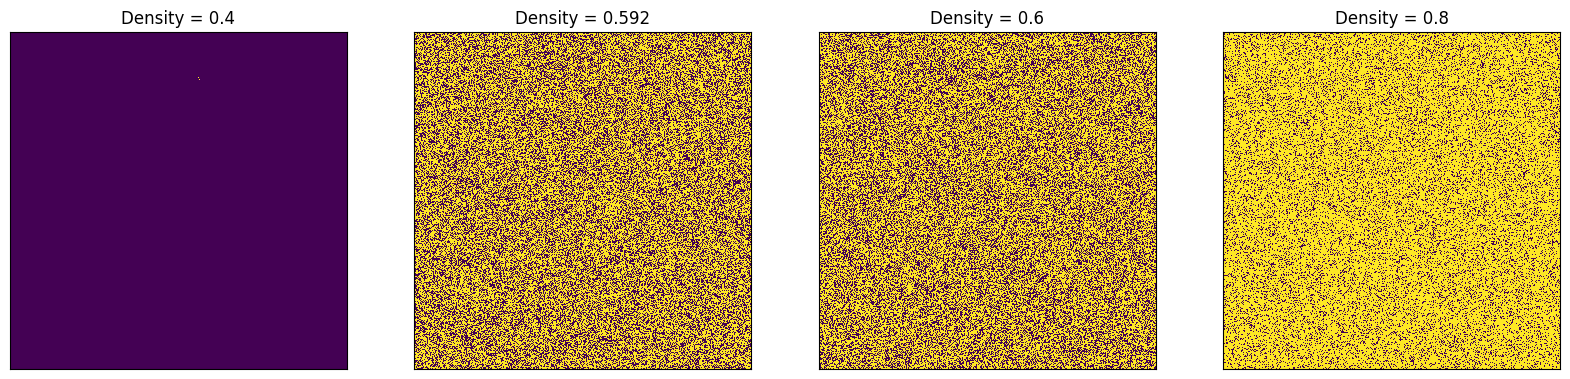

In [ ]:
#equivalent to study properties of the largest cluster only
#here we do the same as above but isolate the largest cluster

grid_size = 5000

#0.592 is the true critical point and 0.6 is the estimate from the previous graph
density_list = [0.4, 0.592,0.6, 0.8]

count = 0
fig, axs = plt.subplots(1,4)



for density in density_list:
    #make a random grid of 0s and 1s
    z = rand(grid_size,grid_size)
    m = z<density

    lw = measurements.label(m, neighbourKernal)
    lw = lw[0]

    rp = measure.regionprops(lw)
    # get size of largest cluster
    size = max([i.area for i in rp])

    out = morphology.remove_small_objects(lw, min_size=size-1)
    out[where(out > 0)] = 1

    axs[count].imshow(out, interpolation='None')



    axs[count].set_title('Density = ' + str(density))
    axs[count].set_xticks([])
    axs[count].set_yticks([])

    count += 1

    fig.set_size_inches(20, 20)

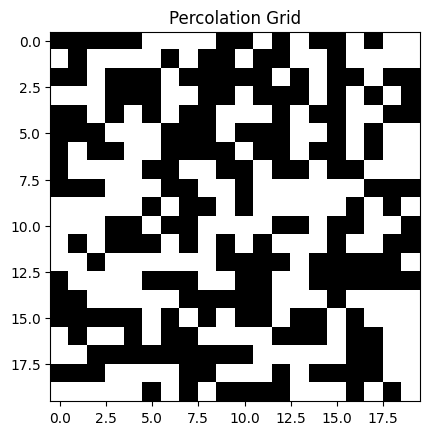

The grid does not percolate.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_grid(size, p):
    """Create a grid of given size with open cells based on probability p."""
    return np.random.rand(size, size) < p

def percolates(grid):
    """Check if the grid percolates from top to bottom."""
    size = grid.shape[0]
    visited = np.zeros_like(grid, dtype=bool)

    def dfs(x, y):
        if x < 0 or x >= size or y < 0 or y >= size or visited[x, y] or not grid[x, y]:
            return False
        visited[x, y] = True
        if x == size - 1:
            return True
        return dfs(x + 1, y) or dfs(x - 1, y) or dfs(x, y + 1) or dfs(x, y - 1)

    for y in range(size):
        if grid[0, y] and dfs(0, y):
            return True
    return False

def visualize_grid(grid):
    """Visualize the grid using Matplotlib."""
    plt.imshow(grid, cmap='binary')
    plt.title('Percolation Grid')
    plt.show()

# Parameters
size = 20  # Size of the grid
p = 0.5    # Probability of a cell being open

# Create and visualize the grid
grid = create_grid(size, p)
visualize_grid(grid)

# Check if the grid percolates
if percolates(grid):
    print("The grid percolates!")
else:
    print("The grid does not percolate.")


Frames generated. Use a tool like FFmpeg to compile them into a video.


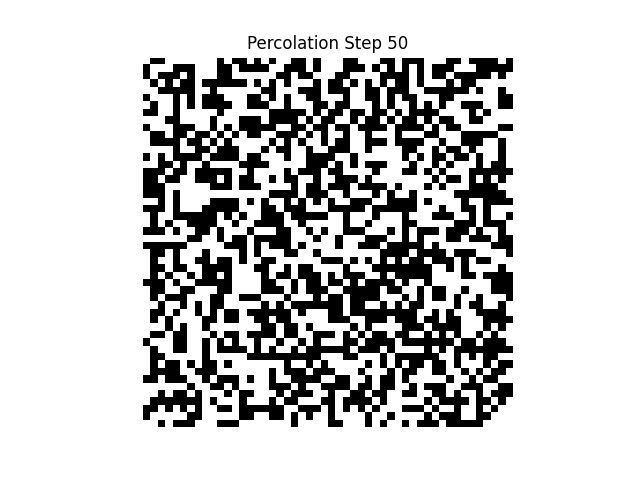

In [ ]:
# Install required libraries
!pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import os

def create_grid(size, p):
    """Create a grid of given size with open cells based on probability p."""
    return np.random.rand(size, size) < p

def visualize_grid(grid, step):
    """Visualize the grid and save the image."""
    plt.imshow(grid, cmap='binary')
    plt.title(f'Percolation Step {step}')
    plt.axis('off')
    plt.savefig(f'frames/frame_{step:03d}.png')
    plt.close()

# Parameters
size = 50  # Size of the grid
steps = 100  # Number of steps
output_dir = 'frames'

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate frames
for step in range(steps):
    p = step / steps  # Gradually increase the probability
    grid = create_grid(size, p)
    visualize_grid(grid, step)

print("Frames generated. Use a tool like FFmpeg to compile them into a video.")

# Display a sample frame
from IPython.display import Image
Image('frames/frame_050.png')


In [ ]:
# Install FFmpeg
!apt-get install ffmpeg

# Compile images into a video
!ffmpeg -framerate 10 -i frames/frame_%03d.png -c:v libx264 -r 30 -pix_fmt yuv420p coffee_percolation.mp4


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq -

In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Function to display video
def display_video(video_path):
    video_file = open(video_path, "rb").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="600" controls>
                      <source src="{video_url}" type="video/mp4">
                    </video>""")

# Display the video
display_video('coffee_percolation.mp4')


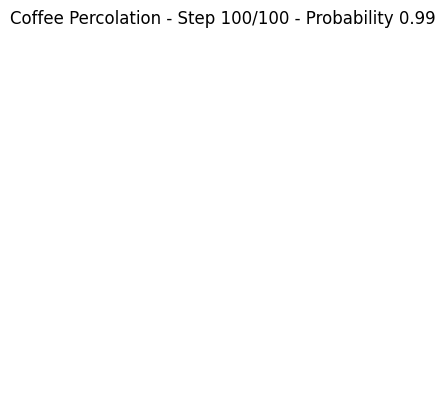

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_grid(size, p):
    """Create a grid of given size with open cells based on probability p."""
    return np.random.rand(size, size) < p

def update_grid(frame, size, steps, img, ax, progress_bar):
    """Update the grid for each frame."""
    p = frame / steps  # Gradually increase the probability
    grid = create_grid(size, p)
    img.set_array(grid)

    # Update progress bar
    progress_bar.set_width(p)
    ax.set_title(f'Coffee Percolation - Step {frame+1}/{steps} - Probability {p:.2f}')

    return [img, progress_bar]

# Parameters
size = 50  # Size of the grid
steps = 100  # Number of steps

# Create figure and axis
fig, ax = plt.subplots()
ax.axis('off')

# Initialize grid
initial_grid = create_grid(size, 0)
cmap = ListedColormap(['white', 'black'])  # White for closed, black for open
img = ax.imshow(initial_grid, cmap=cmap, interpolation='nearest')

# Add progress bar
progress_bar = plt.Rectangle((0, -0.1), 0, 0.05, transform=ax.transAxes, color='blue')
ax.add_patch(progress_bar)

# Create animation
ani = animation.FuncAnimation(fig, update_grid, frames=steps, fargs=(size, steps, img, ax, progress_bar), blit=True)

# Save the animation
ani.save('coffee_percolation.mp4', writer='ffmpeg', fps=10)

# Display the animation
display_video('coffee_percolation.mp4')


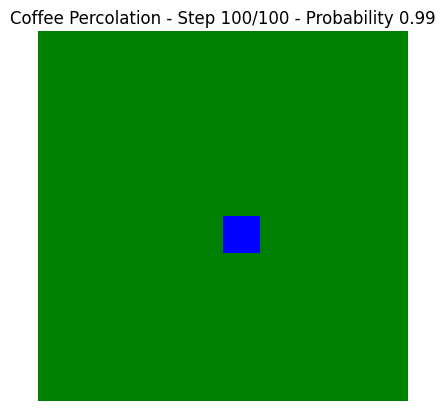

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap

def create_grid(size, p):
    """Create a grid of given size with open cells based on probability p."""
    return np.random.rand(size, size) < p

def update_grid(frame, size, steps, img, ax, progress_bar):
    """Update the grid for each frame."""
    p = frame / steps  # Gradually increase the probability
    grid = create_grid(size, p)
    img.set_array(grid)

    # Update progress bar
    progress_bar.set_width(p)
    ax.set_title(f'Coffee Percolation - Step {frame+1}/{steps} - Probability {p:.2f}')

    return [img, progress_bar]

# Parameters
size = 10  # Size of the grid
steps = 100  # Number of steps

# Create figure and axis
fig, ax = plt.subplots()
ax.axis('off')

# Initialize grid
initial_grid = create_grid(size, 0.5)
cmap = ListedColormap(['blue', 'green'])  # White for closed, black for open
img = ax.imshow(initial_grid, cmap=cmap, interpolation='nearest')

# Add progress bar
progress_bar = plt.Rectangle((0, -0.1), 0, 0.05, transform=ax.transAxes, color='blue')
ax.add_patch(progress_bar)

# Create animation
ani = animation.FuncAnimation(fig, update_grid, frames=steps, fargs=(size, steps, img, ax, progress_bar), blit=True)

# Save the animation
ani.save('coffee_percolation.mp4', writer='ffmpeg', fps=10)

# Display the animation
from IPython.display import HTML
from base64 import b64encode

def display_video(video_path):
    video_file = open(video_path, "rb").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="600" controls>
                      <source src="{video_url}" type="video/mp4">
                    </video>""")

display_video('coffee_percolation.mp4')


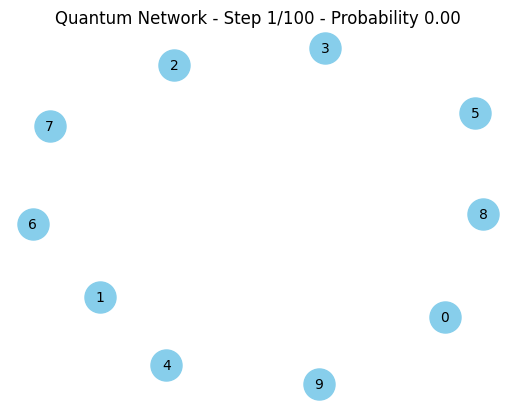

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx

def create_quantum_network(size, p):
    """Create a quantum network with given size and probability p for entanglement links."""
    G = nx.erdos_renyi_graph(size, p)
    return G

def update_quantum_network(frame, size, steps, ax):
    """Update the quantum network for each frame."""
    p = frame / steps  # Gradually increase the probability
    G = create_quantum_network(size, p)
    ax.clear()
    nx.draw(G, ax=ax, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=10)
    ax.set_title(f'Quantum Network - Step {frame+1}/{steps} - Probability {p:.2f}')
    return ax

# Parameters
size = 10  # Number of nodes
steps = 100  # Number of steps

# Create figure and axis
fig, ax = plt.subplots()

# Create animation
ani = animation.FuncAnimation(fig, update_quantum_network, frames=steps, fargs=(size, steps, ax), blit=False)

# Save the animation
ani.save('quantum_network.mp4', writer='ffmpeg', fps=10)

# Display the animation
from IPython.display import HTML
from base64 import b64encode

def display_video(video_path):
    video_file = open(video_path, "rb").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="600" controls>
                      <source src="{video_url}" type="video/mp4">
                    </video>""")

display_video('quantum_network.mp4')


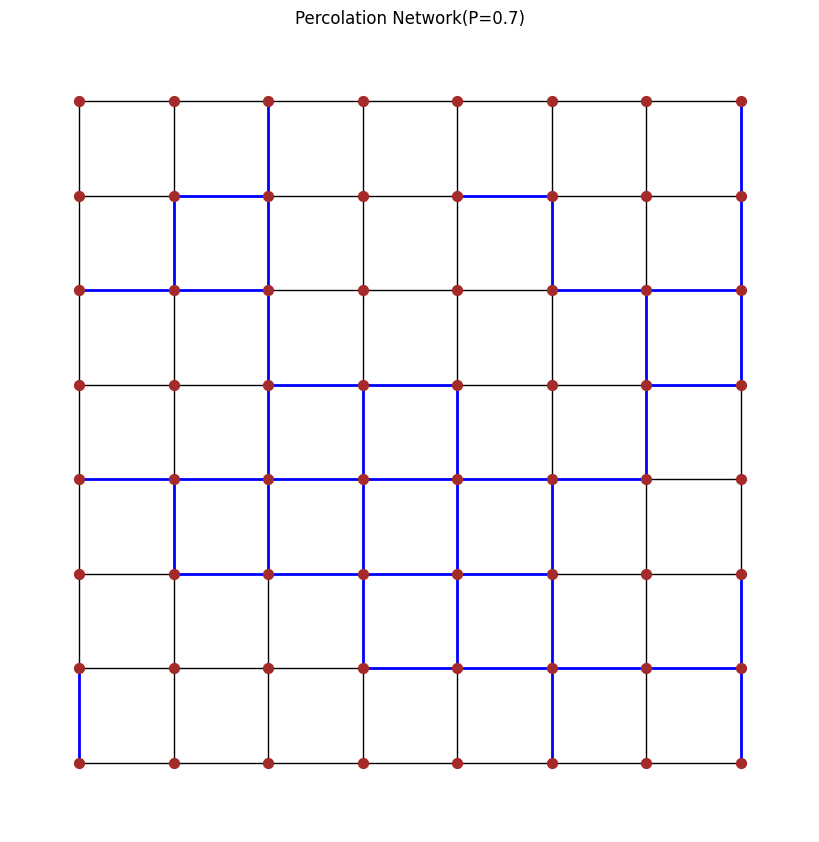

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def generate_percolation_network(size, p):
    """
    Generate a percolation network of given size with probability p for open nodes.
    """
    G = nx.grid_2d_graph(size, size)
    for node in G.nodes():
        G.nodes[node]['state'] = 'open' if np.random.rand() < p else 'closed'
    return G

def plot_percolation_network(G):
    """
    Plot the percolation network, coloring edges based on the state of connected nodes.
    """
    pos = {(x, y): (x, y) for x, y in G.nodes()}
    edge_colors = []
    edge_widths = []

    for edge in G.edges():
        node1, node2 = edge
        if G.nodes[node1]['state'] == 'open' and G.nodes[node2]['state'] == 'open':
            edge_colors.append('blue')
            edge_widths.append(2.0)  # Thicker line for open edges
        else:
            edge_colors.append('black')
            edge_widths.append(1.0)  # Thinner line for closed edges

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, node_color='brown', edge_color=edge_colors, width=edge_widths, with_labels=False, node_size=50)
    plt.title('Percolation Network(P=0.7)')
    plt.show()

# Parameters
grid_size = 8  # Size of the grid (10x10)
probability = 0.7  # Probability of a node being open

# Generate and plot the percolation network
percolation_network = generate_percolation_network(grid_size, probability)
plot_percolation_network(percolation_network)


/usr/local/lib/python3.10/dist-packages/matplotlib/animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


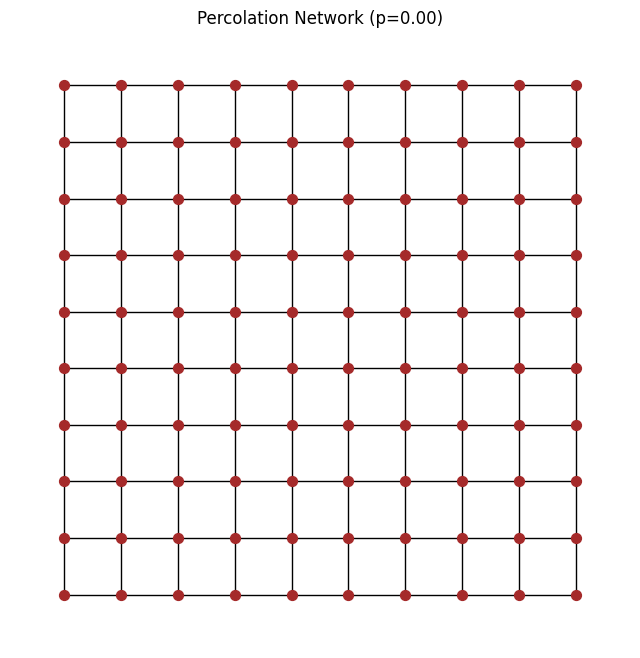

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def generate_percolation_network(size, p):
    G = nx.grid_2d_graph(size, size)
    for node in G.nodes():
        G.nodes[node]['state'] = 'open' if np.random.rand() < p else 'closed'
    return G

def update(frame, G, pos, ax):
    p = frame / 100
    for node in G.nodes():
        G.nodes[node]['state'] = 'open' if np.random.rand() < p else 'closed'

    edge_colors = []
    edge_widths = []

    for edge in G.edges():
        node1, node2 = edge
        if G.nodes[node1]['state'] == 'open' and G.nodes[node2]['state'] == 'open':
            edge_colors.append('blue')
            edge_widths.append(2.0)
        else:
            edge_colors.append('black')
            edge_widths.append(1.0)

    ax.clear()
    nx.draw(G, pos, node_color='brown', edge_color=edge_colors, width=edge_widths, with_labels=False, node_size=50)
    ax.set_title(f'Percolation Network (p={p:.2f})')

grid_size = 10
frames = 101

percolation_network = generate_percolation_network(grid_size, 0)
pos = {(x, y): (x, y) for x, y in percolation_network.nodes()}

fig, ax = plt.subplots(figsize=(8, 8))
ani = animation.FuncAnimation(fig, update, frames=frames, fargs=(percolation_network, pos, ax), interval=200)

HTML(ani.to_jshtml())


Moviepy - Building video slowed_percolation_network.mp4.
Moviepy - Writing video slowed_percolation_network.mp4



Moviepy - Done !
Moviepy - video ready slowed_percolation_network.mp4


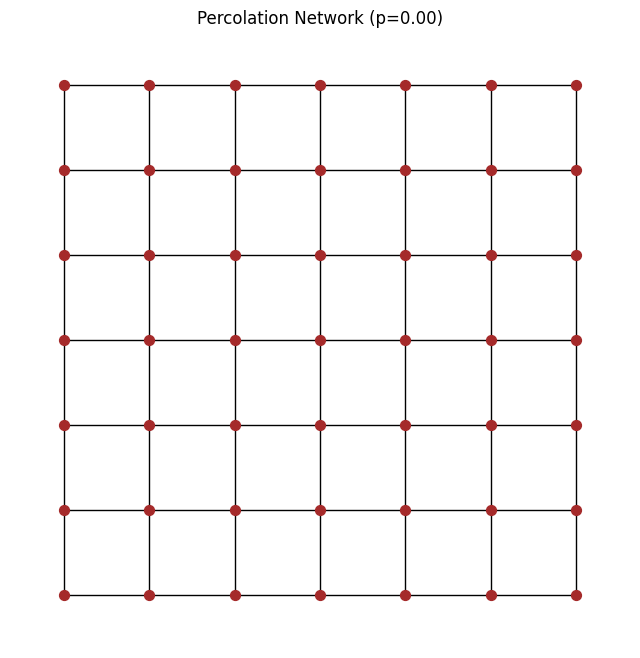

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from moviepy.editor import VideoFileClip
from IPython.display import HTML

def generate_percolation_network(size, p):
    G = nx.grid_2d_graph(size, size)
    for node in G.nodes():
        G.nodes[node]['state'] = 'open' if np.random.rand() < p else 'closed'
    return G

def update(frame, G, pos, ax):
    p = frame / 1024
    for node in G.nodes():
        G.nodes[node]['state'] = 'open' if np.random.rand() < p else 'closed'

    edge_colors = []
    edge_widths = []

    for edge in G.edges():
        node1, node2 = edge
        if G.nodes[node1]['state'] == 'open' and G.nodes[node2]['state'] == 'open':
            edge_colors.append('blue')
            edge_widths.append(2.0)
        else:
            edge_colors.append('black')
            edge_widths.append(1.0)

    ax.clear()
    nx.draw(G, pos, node_color='brown', edge_color=edge_colors, width=edge_widths, with_labels=False, node_size=50)
    ax.set_title(f'Percolation Network (p={p:.2f})')

grid_size = 7
frames = 1024

percolation_network = generate_percolation_network(grid_size, 0)
pos = {(x, y): (x, y) for x, y in percolation_network.nodes()}

fig, ax = plt.subplots(figsize=(8, 8))
ani = animation.FuncAnimation(fig, update, frames=frames, fargs=(percolation_network, pos, ax), interval=200)

ani.save('percolation_network.mp4', writer='ffmpeg', fps=10)

# Load the video and slow it down by 50%
clip = VideoFileClip('percolation_network.mp4')
slowed_clip = clip.fx(clip.speedx, 0.5)
slowed_clip.write_videofile('slowed_percolation_network.mp4')

# Display the slowed video
HTML("""
<video width="640" height="480" controls>
  <source src="slowed_percolation_network.mp4" type="video/mp4">
</video>
""")
